In [1]:
import numpy as np
# np.random.seed(42)
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
sns.set(style="whitegrid")
from collections import Counter

from datetime import datetime

# data balancing
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler, KBinsDiscretizer
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score, precision_recall_curve
import itertools

from sklearn.compose import ColumnTransformer
import joblib
# from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# from sklearn.linear_model import  LogisticRegression


from keras.models import Sequential

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from collections import Counter
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, SpatialDropout1D
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import regularizers



import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
def quantile_label(quantile_split, feature_values, duplicates=False):
#Function to define the lower & upper limits after pd.qcut (quantile cut)
#applicable for numeric (continue) feature
#INPUT :
#quantile_split: list of intervals of split; for example quantile_split = [0, 0.25, 0.5, 0.75, 1]
#feature_values : all values of the feature to split (for example : feature_values = df['age'])

#duplicates : if there is one duplicate in qantile cut, the bins numbre reduce to len(quantile_split) - 2
#else : no duplicate : n_bins = len(quantile_split)-1


    feature_quantile = feature_values.quantile(quantile_split)
        #lower_limit = quantile_split[i]
        #upper_limit = quantile_split[i+1]
        #print(str(int(feature_quantile[lower_limit])) + '_' + str(int(feature_quantile[upper_limit])))
    if duplicates==True:
      return [f'{int(feature_quantile[quantile_split[i]])}_{int(feature_quantile[quantile_split[i+1]])}' for i in range(len(quantile_split)-2)]
    else:
      return [f'{int(feature_quantile[quantile_split[i]])}_{int(feature_quantile[quantile_split[i+1]])}' for i in range(len(quantile_split)-1)]

In [3]:
def quantile_split(n_bins, feature, duplicates='raise'):
    split = np.linspace(0,1,n_bins+1)
    feature_split = feature.quantile(split)

    if duplicates == 'drop':
        labels = [f'{round(feature_split[split[i]])}_{round(feature_split[split[i+1]])}' for i in range(n_bins-1)]
    else:
        labels = [f'{round(feature_split[split[i]])}_{round(feature_split[split[i+1]])}' for i in range(n_bins)]

    feature_quantile = pd.qcut(feature, q=split, duplicates='drop', labels=labels)

    return feature_quantile

In [5]:
df_country = pd.read_csv(r"C:\Users\User\Desktop\IpAddress_to_Country.csv")
df_country.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [6]:
df = pd.read_csv(r"C:\Users\User\Desktop\Fraud_Data.csv")
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


#Merge 2 datasets by ip_address

In [7]:
# Create an IntervalIndex using lower_bound_ip_address and upper_bound_ip_address
idx = pd.IntervalIndex.from_arrays(df_country['lower_bound_ip_address'], df_country['upper_bound_ip_address'], closed='both')
country = df_country.iloc[idx.get_indexer(df['ip_address'])]['country']

df['country'] = country.values
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,United States
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,Australia
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States


In [8]:
df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
country           0
dtype: int64

Country :
* count_country : total count of purchases
* category_country : qcut by using quantile (0, 0.25, 0.5, 0.75, 1)

In [9]:
df['count_country'] = df['country'].map(df['country'].value_counts())
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country,count_country
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan,7306
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States,58049
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,United States,58049
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,Australia,23810
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States,58049


In [10]:
# Create a new column 'category_country' and categorize the count of occurrences of each country into intervals
df['category_country'] = quantile_split(n_bins=5, feature=df['count_country'], duplicates='drop')

In [11]:
df['category_country'].value_counts()

23810_58049    58049
2961_12038     37778
1_2961         31475
12038_23810    23810
Name: category_country, dtype: int64

In [12]:
# Count the occurrences of unique IP addresses where
# class is equal to 1 (fraudulent transactions)
df.loc[df['class']==1]['ip_address'].value_counts()

3.484934e+08    19
3.874758e+09    19
2.050964e+09    19
1.502818e+09    19
5.760609e+08    19
                ..
2.337532e+09     1
1.477500e+09     1
2.618542e+09     1
3.816468e+09     1
3.451155e+09     1
Name: ip_address, Length: 7277, dtype: int64

In [13]:
# Count the occurrences of each unique IP address and map it to the 'ip_address' column

df['count_ip'] = df['ip_address'].map(df['ip_address'].value_counts())
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country,count_country,category_country,count_ip
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan,7306,2961_12038,1
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States,58049,23810_58049,1
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,United States,58049,23810_58049,12
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,Australia,23810,12038_23810,1
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States,58049,23810_58049,1


#Transform signup_time, purchase_time to datetime

Define online-time based on sigup_time and purchase_time

In [14]:
df[['signup_time', 'purchase_time']] = df[['signup_time', 'purchase_time']].apply(pd.to_datetime, errors='coerce')
df['online_time'] = (df['purchase_time'] - df['signup_time'])

# Calculate the time spent online for each user in minutes
df['online_time'] = df['online_time'].dt.seconds // 60


In [15]:
df['class'].value_counts()/df['class'].shape[0]

0    0.906354
1    0.093646
Name: class, dtype: float64

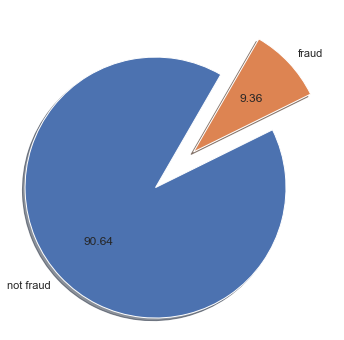

In [16]:
plt.figure(figsize=(6,6))
plt.pie(df['class'].value_counts()/df['class'].shape[0], explode=(0.2,0.2),
        shadow=True, autopct='%.2f', startangle=60, labels=['not fraud', 'fraud'])
plt.rc('font', size=23)

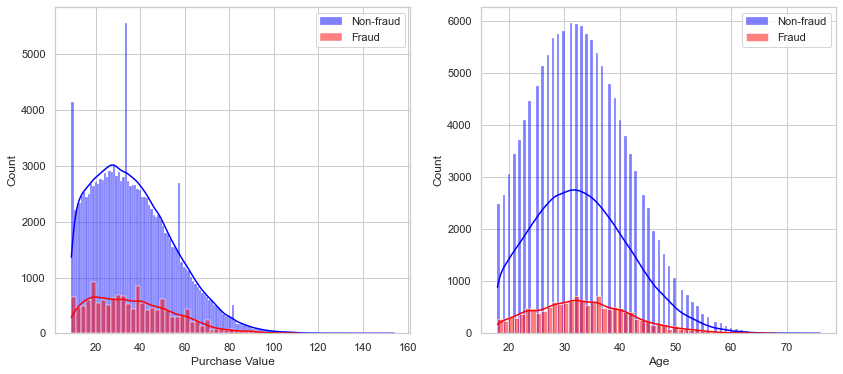

In [17]:
plt.figure(figsize=(14,6))

plt.subplot(121)
sns.histplot((df[(df['class']==0)]['purchase_value']), kde=True, color='blue', label='Non-fraud')
sns.histplot((df[(df['class']==1)]['purchase_value']), kde=True, color='red', label='Fraud')
plt.xlabel('Purchase Value')
plt.legend()

plt.subplot(122)
sns.histplot(df[(df['class']==0)]['age'], kde=True, color='blue', label='Non-fraud')
sns.histplot(df[(df['class']==1)]['age'], kde=True, color='red', label='Fraud')
plt.xlabel('Age')
plt.legend()

plt.show()

<AxesSubplot:xlabel='browser', ylabel='count'>

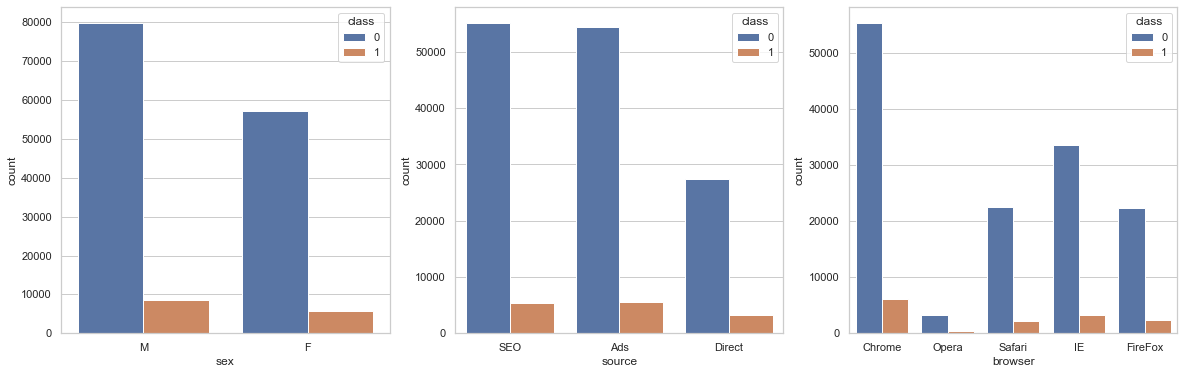

In [18]:
plt.figure(figsize=(20,6))
plt.subplot(131)
sns.countplot(x='sex', hue='class', data=df)

plt.subplot(132)
sns.countplot(x='source', hue='class', data=df)

plt.subplot(133)
sns.countplot(x='browser', hue='class', data=df)

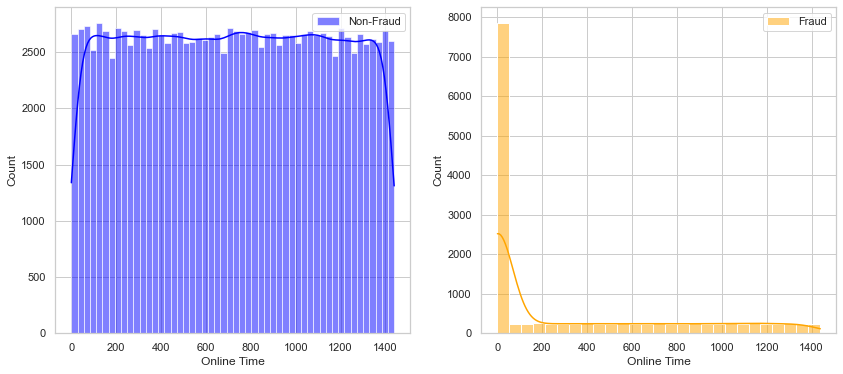

In [19]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[df['class'] == 0]['online_time'], kde=True, color='blue', label='Non-Fraud')
plt.xlabel('Online Time')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df[df['class'] == 1]['online_time'], kde=True, color='orange', label='Fraud')
plt.xlabel('Online Time')
plt.legend()

plt.show()


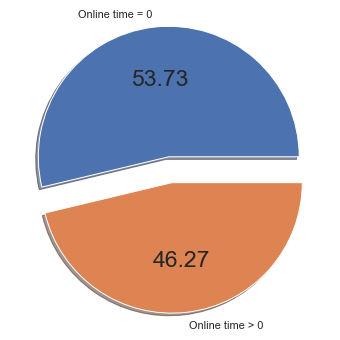

In [20]:
fraud_at_0 = df[(df['class']==1) & (df['online_time']==0)].shape[0]/df[df['class']==1].shape[0]
#print(fraud_at_0)
fraud_time_online = [fraud_at_0, (1-fraud_at_0)]

plt.figure(figsize=(6,6))
plt.pie(fraud_time_online, explode=(0.1, 0.1), labels=['Online time = 0', 'Online time > 0'], autopct='%.2f', shadow=True, startangle=0)
plt.rc('font', size=20)

<AxesSubplot:xlabel='class', ylabel='online_time'>

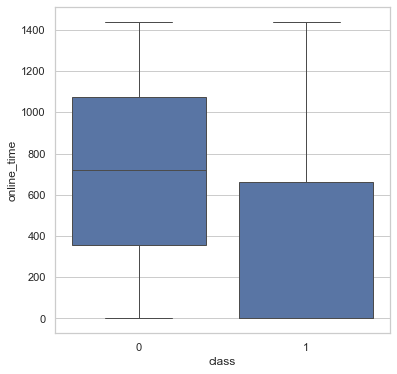

In [21]:
plt.figure(figsize=(6,6))
sns.boxplot(y='online_time', x='class', data=df)

All purchase with online time in first minute is fraud. There's no reason that someone pays without seeing products.

## Classification model to predict fraud

In [22]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country,count_country,category_country,count_ip,online_time
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan,7306,2961_12038,1,231
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States,58049,23810_58049,1,299
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,United States,58049,23810_58049,12,0
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,Australia,23810,12038_23810,1,1001
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States,58049,23810_58049,1,691


In [23]:
# df.drop(['user_id', 'count_country', 'count_ip', 'device_id', 'category_country'], axis=1, inplace=True)
df.drop(['device_id',], axis=1, inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           151112 non-null  int64         
 1   signup_time       151112 non-null  datetime64[ns]
 2   purchase_time     151112 non-null  datetime64[ns]
 3   purchase_value    151112 non-null  int64         
 4   source            151112 non-null  object        
 5   browser           151112 non-null  object        
 6   sex               151112 non-null  object        
 7   age               151112 non-null  int64         
 8   ip_address        151112 non-null  float64       
 9   class             151112 non-null  int64         
 10  country           151112 non-null  object        
 11  count_country     151112 non-null  int64         
 12  category_country  151112 non-null  category      
 13  count_ip          151112 non-null  int64         
 14  onli

In [24]:
df['country'].unique()

array(['Japan', 'United States', 'Australia', 'Canada', 'China', 'Brazil',
       'India', 'Argentina', 'United Kingdom', 'South Africa', 'Germany',
       'Mexico', 'Sweden', 'Korea Republic of', 'Peru', 'Portugal',
       'Bangladesh', 'France', 'Taiwan; Republic of China (ROC)',
       'Russian Federation', 'Belgium', 'Denmark', 'Netherlands',
       'Iran (ISLAMIC Republic Of)', 'Spain', 'Gabon', 'Saudi Arabia',
       'Hong Kong', 'Georgia', 'Syrian Arab Republic', 'Turkey',
       'New Zealand', 'European Union', 'Ukraine', 'Austria', 'Israel',
       'Malaysia', 'Greece', 'Italy', 'Norway', 'Poland', 'Venezuela',
       'Thailand', 'Chile', 'Morocco', 'Finland', 'Hungary', 'Indonesia',
       'Colombia', 'Ecuador', 'Lithuania', 'Switzerland', 'Viet Nam',
       'Nigeria', 'Egypt', 'Seychelles', 'Kazakhstan', 'Kenya',
       'Moldova Republic of', 'Trinidad and Tobago', 'Qatar', 'Bolivia',
       'Bulgaria', 'Romania', 'Croatia (LOCAL Name: Hrvatska)', 'Cyprus',
       'Czech Rep

In [25]:
source_mapping = {
    'SEO': 0,
    'Ads': 1,
    'Direct': 2
}
df['source'] = df['source'].map(source_mapping)

sex_mapping = {
    'M': 0,
    'F': 1,
}
df['sex'] = df['sex'].map(sex_mapping)

browser_mapping = {
    'Chrome': 0,
    'IE': 1,
    'Safari': 2,
    'FireFox': 3,
    'Opera': 4,
}
df['browser'] = df['browser'].map(browser_mapping)

In [26]:
country_mapping = {
    'Japan': 0, 'United States': 1, 'Australia': 2, 'Canada': 3, 'China': 4, 'Brazil': 5,
    'India': 6, 'Argentina': 7, 'United Kingdom': 8, 'South Africa': 9, 'Germany': 10,
    'Mexico': 11, 'Sweden': 12, 'Korea Republic of': 13, 'Peru': 14, 'Portugal': 15,
    'Bangladesh': 16, 'France': 17, 'Taiwan; Republic of China (ROC)': 18,
    'Russian Federation': 19, 'Belgium': 20, 'Denmark': 21, 'Netherlands': 22,
    'Iran (ISLAMIC Republic Of)': 23, 'Spain': 24, 'Gabon': 25, 'Saudi Arabia': 26,
    'Hong Kong': 27, 'Georgia': 28, 'Syrian Arab Republic': 29, 'Turkey': 30,
    'New Zealand': 31, 'European Union': 32, 'Ukraine': 33, 'Austria': 34, 'Israel': 35,
    'Malaysia': 36, 'Greece': 37, 'Italy': 38, 'Norway': 39, 'Poland': 40, 'Venezuela': 41,
    'Thailand': 42, 'Chile': 43, 'Morocco': 44, 'Finland': 45, 'Hungary': 46, 'Indonesia': 47,
    'Colombia': 48, 'Ecuador': 49, 'Lithuania': 50, 'Switzerland': 51, 'Viet Nam': 52,
    'Nigeria': 53, 'Egypt': 54, 'Seychelles': 55, 'Kazakhstan': 56, 'Kenya': 57,
    'Moldova Republic of': 58, 'Trinidad and Tobago': 59, 'Qatar': 60, 'Bolivia': 61,
    'Bulgaria': 62, 'Romania': 63, 'Croatia (LOCAL Name: Hrvatska)': 64, 'Cyprus': 65,
    'Czech Republic': 66, 'Algeria': 67, 'Kyrgyzstan': 68, 'Singapore': 69, 'Guam': 70,
    'United Arab Emirates': 71, 'Paraguay': 72, 'Tunisia': 73, 'Dominican Republic': 74,
    'Pakistan': 75, 'Malta': 76, 'Nicaragua': 77, 'Estonia': 78, 'Mozambique': 79,
    'Namibia': 80, 'Macedonia': 81, 'Costa Rica': 82, 'Cuba': 83, 'Ireland': 84,
    'Albania': 85, 'Oman': 86, 'Uruguay': 87, 'Lebanon': 88, 'Puerto Rico': 89,
    'Maldives': 90, 'Turkmenistan': 91, 'Barbados': 92, 'Iceland': 93, 'Philippines': 94,
    'Kuwait': 95, 'Panama': 96, 'New Caledonia': 97, 'Guatemala': 98, 'Ghana': 99,
    'Latvia': 100, 'Malawi': 101, 'Slovenia': 102, 'Senegal': 103,
    'Libyan Arab Jamahiriya': 104, 'Cambodia': 105, 'Belize': 106, 'Mauritius': 107,
    'Slovakia (SLOVAK Republic)': 108, 'Iraq': 109, 'El Salvador': 110,
    'Bosnia and Herzegowina': 111, 'Serbia': 112, 'Luxembourg': 113, 'Belarus': 114,
    "Cote D'ivoire": 115, 'Djibouti': 116, 'Armenia': 117, 'Sri Lanka': 118, 'Sudan': 119,
    'Rwanda': 120, 'Uzbekistan': 121, 'Jordan': 122, 'Bahrain': 123, 'Azerbaijan': 124,
    'South Sudan': 125, 'Virgin Islands (U.S.)': 126, 'Congo': 127, 'Angola': 128,
    'Uganda': 129, 'Jamaica': 130, 'Haiti': 131, 'Papua New Guinea': 132, 'Gibraltar': 133,
    'Cameroon': 134, 'Palestinian Territory Occupied': 135, 'Myanmar': 136, 'Nepal': 137,
    'Brunei Darussalam': 138, 'Zambia': 139, 'Saint Kitts and Nevis': 140, 'Reunion': 141,
    'Botswana': 142, 'Dominica': 143, 'Burkina Faso': 144, 'Montenegro': 145, 'Macau': 146,
    'Tanzania United Republic of': 147, 'Faroe Islands': 148, 'Zimbabwe': 149,
    'Honduras': 150, 'Monaco': 151, 'Congo The Democratic Republic of The': 152,
    'Cayman Islands': 153, 'Niger': 154, 'Antigua and Barbuda': 155, 'Lesotho': 156,
    'Fiji': 157, 'Mongolia': 158, 'Afghanistan': 159, 'Bhutan': 160, 'Bermuda': 161, 'Curacao': 162,
    'Ethiopia': 163, 'Vanuatu': 164, "Lao People's Democratic Republic": 165,
    'British Indian Ocean Territory': 166, 'Bahamas': 167, 'Madagascar': 168,
    'Bonaire; Sint Eustatius; Saba': 169, 'Liechtenstein': 170, 'Gambia': 171,
    'Benin': 172, 'Cape Verde': 173, 'Tajikistan': 174, 'Saint Martin': 175, 'Yemen': 176,
    'San Marino': 177, 'Burundi': 178, 'Nauru': 179, 'Guadeloupe': 180
}

# df['country'] = df['country'].map(browser_mapping)


unique_countries = df['country'].unique()

# Create the mapping dictionary
country_mapping = {country: idx for idx, country in enumerate(unique_countries)}
# Encode the countries
df['country'] = df['country'].map(country_mapping)

In [27]:
# Define columns to scale
columns_to_scale = ['purchase_value', 'age', 'online_time', 'user_id', 'count_country', 'count_ip', 'category_country']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the selected columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Save the fitted scaler to a file
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [28]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,source,browser,sex,age,ip_address,class,country,count_country,category_country,count_ip,online_time
0,0.055140,2015-02-24 22:55:49,2015-04-18 02:47:11,0.172414,0,0,0,0.362069,7.327584e+08,0,0,0.125844,0.124357,0.000000,0.160528
1,0.833299,2015-06-07 20:39:50,2015-06-08 01:38:54,0.048276,1,0,1,0.603448,3.503114e+08,0,1,1.000000,1.000000,0.000000,0.207783
2,0.003393,2015-01-01 18:52:44,2015-01-01 18:52:45,0.041379,0,4,0,0.603448,2.621474e+09,1,1,1.000000,1.000000,0.578947,0.000000
3,0.375207,2015-04-28 21:13:25,2015-05-04 13:54:50,0.241379,0,2,0,0.396552,3.840542e+09,0,2,0.410161,0.505581,0.000000,0.695622
4,0.553410,2015-07-21 07:09:52,2015-09-09 18:40:53,0.206897,1,2,0,0.465517,4.155831e+08,0,1,1.000000,1.000000,0.000000,0.480195


In [29]:
numeric_feats = ['purchase_value', 'age', 'online_time', 'user_id', 'count_country', 'count_ip', 'category_country' ]
categorical_feats = ['source', 'sex', 'browser', 'country']
target = ['class']
df_model = df[numeric_feats + categorical_feats + target]

X = df[numeric_feats + categorical_feats]
y = df['class']

In [30]:
X.shape

(151112, 11)

In [31]:
y.shape

(151112,)

# LDA Feature selection

In [32]:
# Initialize LDA
lda = LinearDiscriminantAnalysis()

# Fit LDA model
lda.fit(X, y)

# Get feature importance scores
feature_importances = lda.coef_

# Print feature importance scores
for i, importance in enumerate(feature_importances[0]):
    print(f"Feature {X.columns[i]} importance: {importance}")

Feature purchase_value importance: -0.04687539468328814
Feature age importance: -0.053558584927610786
Feature online_time importance: -0.9179906425366197
Feature user_id importance: 0.021827936848857435
Feature count_country importance: 0.06257200038058439
Feature count_ip importance: 28.654027606123616
Feature category_country importance: -0.06391678869259573
Feature source importance: 0.12802279219117121
Feature sex importance: -0.04197331477224951
Feature browser importance: -0.004367755565523742
Feature country importance: -0.0007176863885404539


In [33]:
# Get indices of features sorted by importance scores
top_10_indices = np.argsort(np.abs(feature_importances[0]))[::-1][:10]

# Select the top 10 features
top_10_features = X.columns[top_10_indices]

# Print the top 10 features
print("Top 10 Features:")
for feature in top_10_features:
    print(feature)

Top 10 Features:
count_ip
online_time
source
category_country
count_country
age
purchase_value
sex
user_id
browser


In [34]:
X = X[top_10_features]

## SMOTE 

In [35]:
# Instantiate SMOTE
smote = SMOTETomek()  #(random_state=42)

# Apply Random Under-sampling
rs = RandomOverSampler(random_state=42)

# Apply RUS to your data
X_resampled, y_resampled = rs.fit_resample(X, y)

In [36]:
# Print counts of the target variable before applying SMOTE
print("Counts of the Fraud variable before applying SMOTE:")
print(y.value_counts())

# Print counts of the target variable after applying SMOTE
print("\nCounts of the Fraud variable after applying SMOTE:")
print(y_resampled.value_counts())

Counts of the Fraud variable before applying SMOTE:
0    136961
1     14151
Name: class, dtype: int64

Counts of the Fraud variable after applying SMOTE:
0    136961
1    136961
Name: class, dtype: int64


In [37]:
# Perform t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_resampled)

# Plot t-SNE result
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_resampled, cmap='viridis', alpha=0.5)
plt.colorbar()
plt.title('t-SNE visualization of Resampled Data')
plt.show()

KeyboardInterrupt: 

# Divide the dataset into train and test set

In [38]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

In [39]:
X.head()

,count_ip,online_time,source,category_country,count_country,age,purchase_value,sex,user_id,browser
0,0.000000,0.160528,0,0.124357,0.125844,0.362069,0.172414,0,0.055140,0
1,0.000000,0.207783,1,1.000000,1.000000,0.603448,0.048276,1,0.833299,0
2,0.578947,0.000000,0,1.000000,1.000000,0.603448,0.041379,0,0.003393,4
3,0.000000,0.695622,0,0.505581,0.410161,0.396552,0.241379,0,0.375207,2
4,0.000000,0.480195,1,1.000000,1.000000,0.465517,0.206897,0,0.553410,2


# ANN -Feed Forward

In [40]:
#feedforward neural network (FNN)
# Define the model
# model = Sequential()
# model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(1, activation='sigmoid'))

# # Compile the model
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# # Train the model
# model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# # Evaluate the model
# _, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
# _, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# print(f"Train Accuracy: {train_accuracy*100:.2f}%")
# print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Define the model architecture

# Define the model architecture
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
# Compile the model with BinaryCrossentropy loss
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
# ann_history = ann_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)


# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

# Train the model
ann_history = ann_model.fit(X_train, y_train, epochs=10, batch_size=5, validation_split=0.2,
                            callbacks=[early_stopping, reduce_lr])


# Evaluate the model
ann_test_loss, ann_test_accuracy = ann_model.evaluate(X_test, y_test)
print(f'ANN Test Loss: {ann_test_loss}, ANN Test Accuracy: {ann_test_accuracy}')

Epoch 1/10
21760/21760 [==============================] - 45s 2ms/step - loss: 0.2332 - accuracy: 0.9392 - val_loss: 0.1970 - val_accuracy: 0.9546 - lr: 0.0010
Epoch 2/10
21760/21760 [==============================] - 59s 3ms/step - loss: 0.2073 - accuracy: 0.9515 - val_loss: 0.1978 - val_accuracy: 0.9548 - lr: 0.0010
Epoch 3/10
 5386/21760 [======>.......................] - ETA: 31s - loss: 0.2029 - accuracy: 0.9528

KeyboardInterrupt: 

In [41]:
# Predictions
y_pred = ann_model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Classification Report
print("ANN classification Report")
print(classification_report(y_test, y_pred_classes))


473/473 [==============================] - 1s 1ms/step
ANN classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     13697
           1       0.99      0.52      0.68      1415

    accuracy                           0.95     15112
   macro avg       0.97      0.76      0.83     15112
weighted avg       0.96      0.95      0.95     15112



In [42]:
ann_model.save("ann_fd.h5")

In [43]:
# load model
# savedModel=load_model('ann_fd.h5')
# savedModel.summary()

## DANN network

In [44]:
# Define the model architecture for DNN
dnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),  # Dropout with a rate of 0.5 (50% of the neurons will be dropped)
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


# Compile the DANN model
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the DANN model
dnn_history = dnn_model.fit(X_train, y_train, epochs=10, batch_size=5, validation_split=0.1, 
                            callbacks=[early_stopping, reduce_lr])

# Evaluate the DANN model
dnn_test_loss, dnn_test_accuracy = dnn_model.evaluate(X_test, y_test)
print(f'DNN Test Loss: {dnn_test_loss}, DNN Test Accuracy: {dnn_test_accuracy}')


ann_model.save("dnn_fd.h5")

Epoch 1/10
24480/24480 [==============================] - 44s 2ms/step - loss: 0.2381 - accuracy: 0.9392 - val_loss: 0.1976 - val_accuracy: 0.9503 - lr: 0.0010
Epoch 2/10
24480/24480 [==============================] - 40s 2ms/step - loss: 0.1996 - accuracy: 0.9504 - val_loss: 0.1923 - val_accuracy: 0.9517 - lr: 0.0010
Epoch 3/10
24480/24480 [==============================] - 39s 2ms/step - loss: 0.1968 - accuracy: 0.9518 - val_loss: 0.1899 - val_accuracy: 0.9533 - lr: 0.0010
Epoch 4/10
24480/24480 [==============================] - 40s 2ms/step - loss: 0.1975 - accuracy: 0.9518 - val_loss: 0.1890 - val_accuracy: 0.9526 - lr: 0.0010
Epoch 5/10
24480/24480 [==============================] - 40s 2ms/step - loss: 0.1981 - accuracy: 0.9521 - val_loss: 0.1931 - val_accuracy: 0.9516 - lr: 0.0010
Epoch 6/10
24480/24480 [==============================] - 38s 2ms/step - loss: 0.1936 - accuracy: 0.9532 - val_loss: 0.1849 - val_accuracy: 0.9540 - lr: 0.0010
Epoch 7/10
24480/24480 [================

In [45]:
# Make predictions on the validation set using the trained ANN and DANN models
ann_val_predictions = ann_model.predict(X_test)
dnn_val_predictions = dnn_model.predict(X_test)

# Combine the predictions as features for training the meta-model
meta_features = np.concatenate((ann_val_predictions, dnn_val_predictions), axis=1)

# Initialize the meta-model
meta_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=3, learning_rate=0.1, n_estimators=100)


# Train the meta-model using the combined predictions and ground truth labels
meta_model.fit(meta_features, y_test)

# Make predictions on the test set using the trained ANN and DANN models
ann_test_predictions = ann_model.predict(X_test)
dnn_test_predictions = dnn_model.predict(X_test)

# Combine the test predictions as features for the meta-model
test_meta_features = np.concatenate((ann_test_predictions, dnn_test_predictions), axis=1)

# Evaluate the performance of the meta-model on the test set
meta_accuracy = meta_model.score(test_meta_features, y_test)
print(f'Meta-model Accuracy: {meta_accuracy}')

473/473 [==============================] - 0s 964us/step
Meta-model Accuracy: 0.9546056114346215


473/473 [==============================] - 1s 1ms/step
ANN Precision: 0.5236749116607774
ANN Recall: 0.9853723404255319
ANN F1-score: 0.683894785417628
ANN Accuracy: 0.9546717840127051
ANN AUC Score: 0.9692182036389497


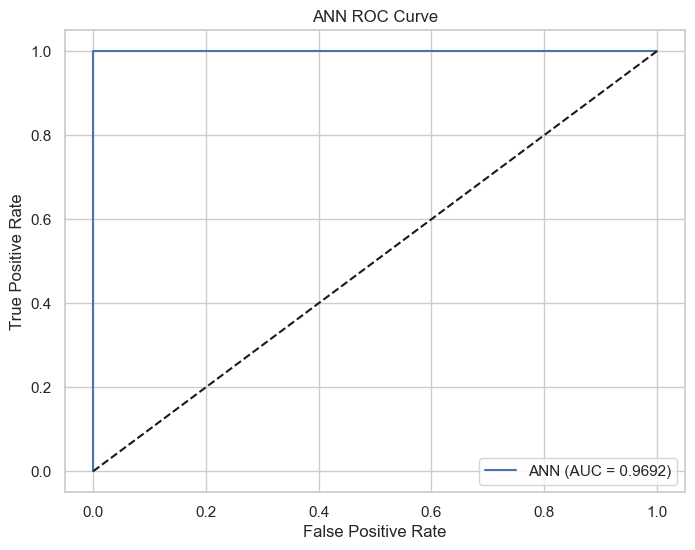

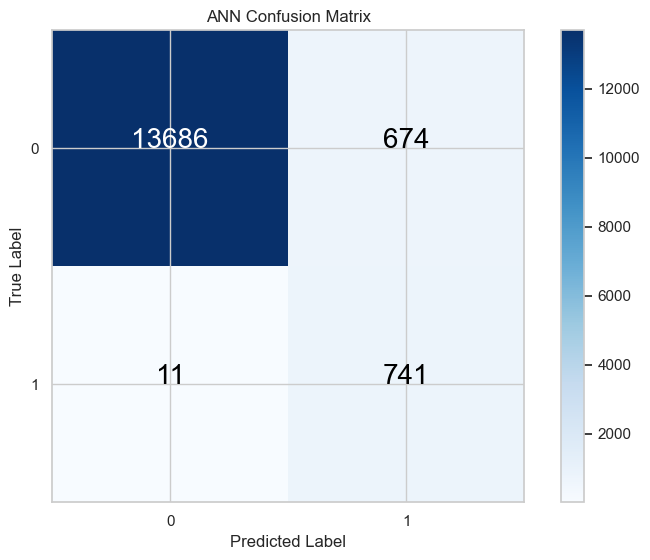

In [46]:
def evaluate_classifier(classifier, X_train, y_train, X_test, y_test, title):
    # Predict the target variable on the training and test data
    y_test_pred = classifier.predict(X_test)
    
    # Convert probabilities to binary classes using a threshold (e.g., 0.5)
    y_test_binary = (y_test_pred > 0.5).astype(int).ravel()
    
    # Calculate precision, recall, and F1-score
    precision = precision_score(y_test_binary, y_test)
    recall = recall_score(y_test_binary, y_test)
    f1 = f1_score(y_test_binary, y_test)
    acc = accuracy_score(y_test_binary, y_test)
    
    # Print precision, recall, and F1-score
    print(f"{title} Precision:", precision)
    print(f"{title} Recall:", recall)
    print(f"{title} F1-score:", f1)
    print(f"{title} Accuracy:", acc)
    
    # Calculate AUC score
    auc_score = roc_auc_score(y_test_binary, y_test)
    print(f"{title} AUC Score:", auc_score)
    
    # Plot ROC curve
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{title} (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    
    # Plot confusion matrix
    cm = confusion_matrix(y_test_binary, y_test)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{title} Confusion Matrix')
    plt.colorbar()
    classes = np.unique(y_test_binary)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()
    
    return precision, recall, f1, acc

ann_precision, ann_recall, ann_f1, ann_cc= evaluate_classifier(ann_model, X_train, y_train, X_test, y_test, "ANN")

473/473 [==============================] - 1s 1ms/step
DNN Precision: 0.46925795053003533
DNN Recall: 0.9955022488755623
DNN F1-score: 0.6378482228626321
DNN Accuracy: 0.9501058761249338
DNN AUC Score: 0.9717559704052439


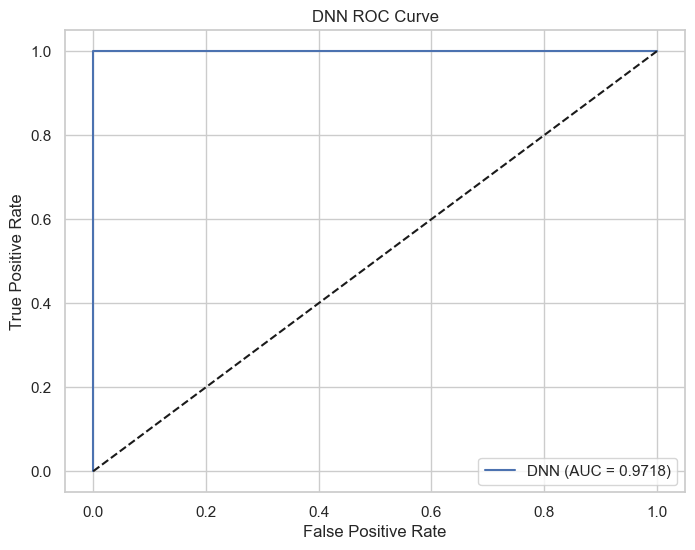

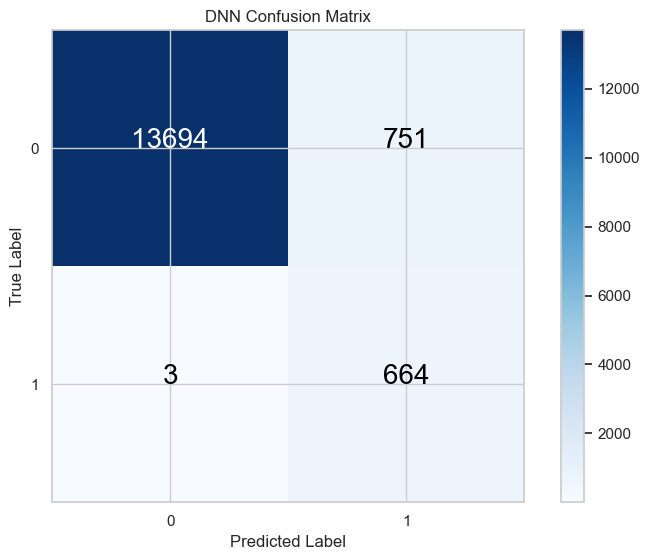

In [47]:
dnn_precision, dnn_recall, dnn_f1, dnn_cc = evaluate_classifier(dnn_model, X_train, y_train, X_test, y_test, "DNN")

Hybrid Precision: 0.5215547703180212
Hybrid Recall: 0.9879518072289156
Hybrid F1-score: 0.6827012025901943
Hybrid Accuracy: 0.9546056114346215
Hybrid AUC Score: 0.9704116850276147


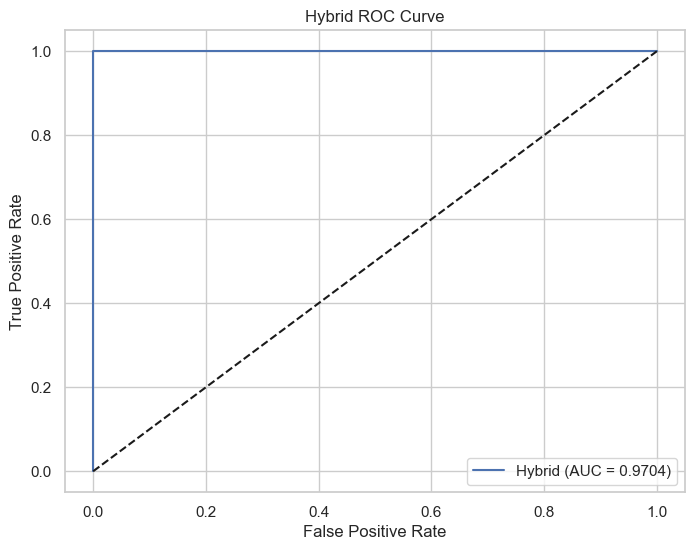

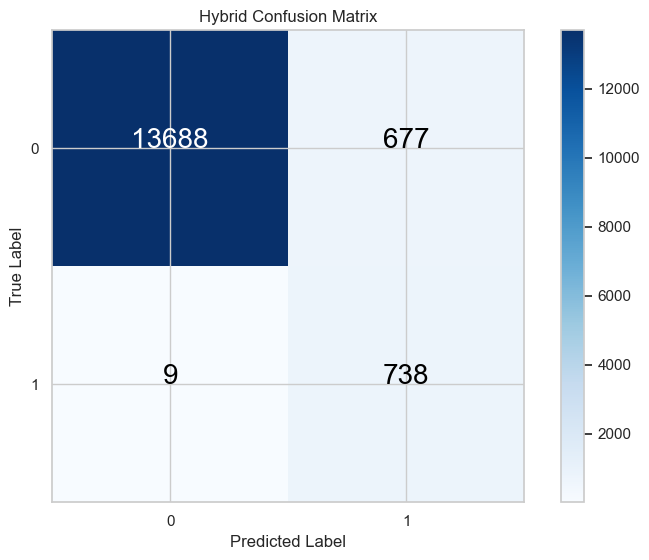

In [48]:
meta_precision, meta_recall, meta_f1, meta_cc = evaluate_classifier(meta_model, meta_features, y_train, test_meta_features, y_test, "Hybrid")

# Random forest model

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the results
print(f'Accuracy: {accuracy:.4f}')
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.9559
Confusion Matrix:
[[13697     0]
 [  667   748]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     13697
           1       1.00      0.53      0.69      1415

    accuracy                           0.96     15112
   macro avg       0.98      0.76      0.83     15112
weighted avg       0.96      0.96      0.95     15112



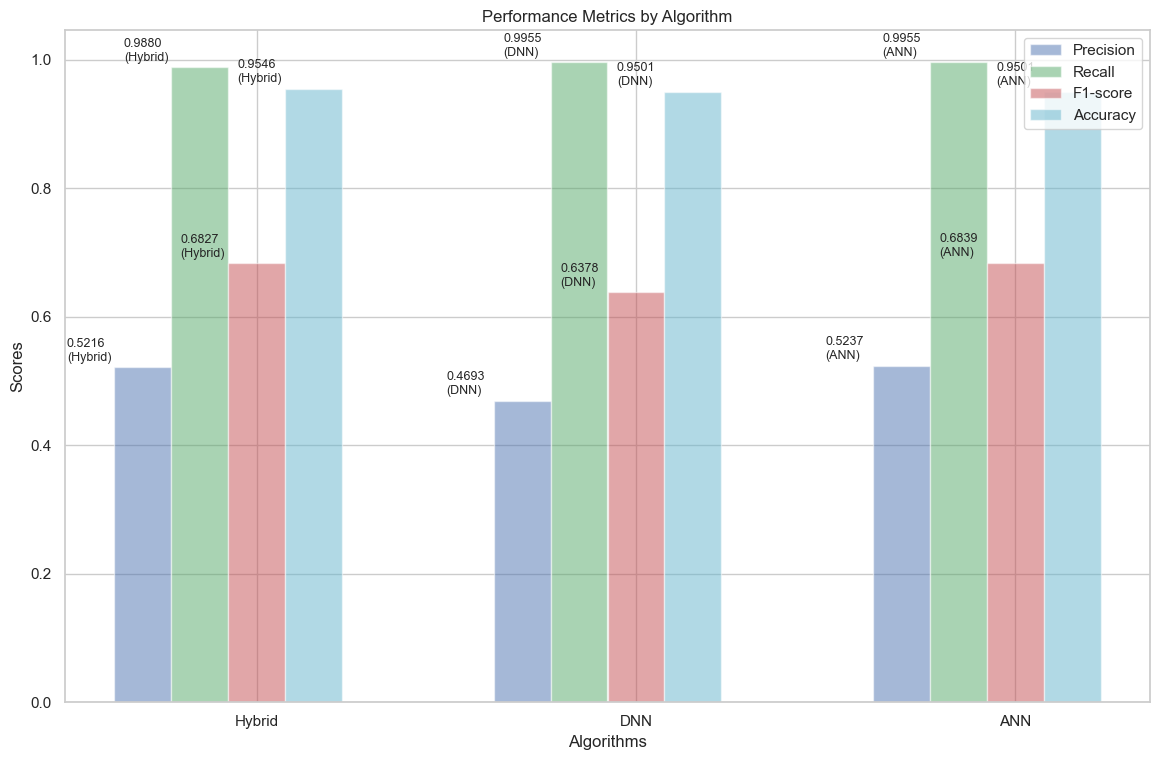

In [49]:
# Metrics for each algorithm
algorithms = ['Hybrid', 'DNN', 'ANN']
precision = [meta_precision, dnn_precision, ann_precision]
recall = [meta_recall, dnn_recall, dnn_recall]
f1_score = [meta_f1, dnn_f1, ann_f1]
accuracy = [meta_cc, dnn_cc, dnn_cc]

# Append the scores to the metric lists
precision_labels = [f"{prec:.4f}\n({alg})" for prec, alg in zip(precision, algorithms)]
recall_labels = [f"{rec:.4f}\n({alg})" for rec, alg in zip(recall, algorithms)]
f1_score_labels = [f"{f1:.4f}\n({alg})" for f1, alg in zip(f1_score, algorithms)]
accuracy_labels = [f"{acc:.4f}\n({alg})" for acc, alg in zip(accuracy, algorithms)]

# Plotting the bar chart
bar_width = 0.15
index = np.arange(len(algorithms))

plt.figure(figsize=(12, 8))

plt.bar(index, precision, bar_width, label='Precision', color='b', alpha=0.5)
plt.bar(index + bar_width, recall, bar_width, label='Recall', color='g', alpha=0.5)
plt.bar(index + 2*bar_width, f1_score, bar_width, label='F1-score', color='r', alpha=0.5)
plt.bar(index + 3*bar_width, accuracy, bar_width, label='Accuracy', color='c', alpha=0.5)


plt.xlabel('Algorithms')
plt.ylabel('Scores')
plt.title('Performance Metrics by Algorithm')
plt.xticks(index + 2*bar_width, algorithms)
plt.legend()

# Annotate the bars with scores
for i, score_list in enumerate([precision_labels, recall_labels, f1_score_labels, accuracy_labels]):
    for j, score in enumerate(score_list):
        plt.text(j - 0.2 + i*bar_width, float(score.split('\n')[0]) + 0.01, score, fontsize=9)

plt.tight_layout()
plt.show()